In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
try:
    df = pd.read_csv("sample_sales_data.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: File not found.")

# Display the first few rows
print("\nFirst 5 rows of the dataset:")
print(df.head())    

Dataset loaded successfully.

First 5 rows of the dataset:
         Date Region     Product  Quantity  Unit Price  Total Sales
0  2023-01-01   West      Laptop         4         800         3200
1  2023-01-02   East      Tablet         7         200         1400
2  2023-01-03  South     Monitor        11         300         3300
3  2023-01-04   West  Headphones        12         100         1200
4  2023-01-05  North      Tablet         2         200          400


In [2]:
# Check structure
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Region       100 non-null    object
 2   Product      100 non-null    object
 3   Quantity     100 non-null    int64 
 4   Unit Price   100 non-null    int64 
 5   Total Sales  100 non-null    int64 
dtypes: int64(3), object(3)
memory usage: 4.8+ KB
None


In [3]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date           0
Region         0
Product        0
Quantity       0
Unit Price     0
Total Sales    0
dtype: int64


In [5]:
# Convert 'Date' to datetime
df['Date'] = pd.to_datetime(df['Date'])
print(df['Date'].head())


0   2023-01-01
1   2023-01-02
2   2023-01-03
3   2023-01-04
4   2023-01-05
Name: Date, dtype: datetime64[ns]


In [6]:
data = pd.read_csv('sample_sales_data.csv')
data.describe()

,Quantity,Unit Price,Total Sales
count,100.00000,100.000000,100.000000
mean,10.23000,378.000000,3887.000000
std,5.43809,236.805337,3419.334657
min,1.00000,100.000000,200.000000
25%,6.00000,200.000000,1400.000000
50%,10.00000,300.000000,2900.000000
75%,15.00000,500.000000,5525.000000
max,20.00000,800.000000,14400.000000


In [7]:
# Group by 'Region' and compute the mean of 'Total Sales' for each region
region_sales_mean = data.groupby('Region')['Total Sales'].mean()

# Print the result
print(region_sales_mean)


Region
East     4652.173913
North    4070.370370
South    3716.000000
West     3156.000000
Name: Total Sales, dtype: float64


In [8]:
# Filter for laptops sold in the West region
laptops_west = data[(data['Region'] == 'West') & (data['Product'] == 'Laptop')]

# Sum the quantity sold
total_laptops_west = laptops_west['Quantity'].sum()

# Print the result
print("Total laptops sold in the West region:", total_laptops_west)


Total laptops sold in the West region: 21


In [9]:
# Filter only headphone sales
headphones_data = data[data['Product'] == 'Headphones']

# Group by Region and sum Quantity
headphones_per_region = headphones_data.groupby('Region')['Quantity'].sum()

# Print the result
print("Number of headphones sold in each region:")
print(headphones_per_region)


Number of headphones sold in each region:
Region
East     21
North    55
South    78
West     33
Name: Quantity, dtype: int64


In [10]:
# Filter for monitor sales
monitors_data = data[data['Product'] == 'Monitor']

# Group by Region and sum Total Sales
monitor_sales_per_region = monitors_data.groupby('Region')['Total Sales'].sum()

# Print the result
print("Total sales of monitors in each region:")
print(monitor_sales_per_region)


Total sales of monitors in each region:
Region
East      4500
North     8700
South    32100
West     10500
Name: Total Sales, dtype: int64


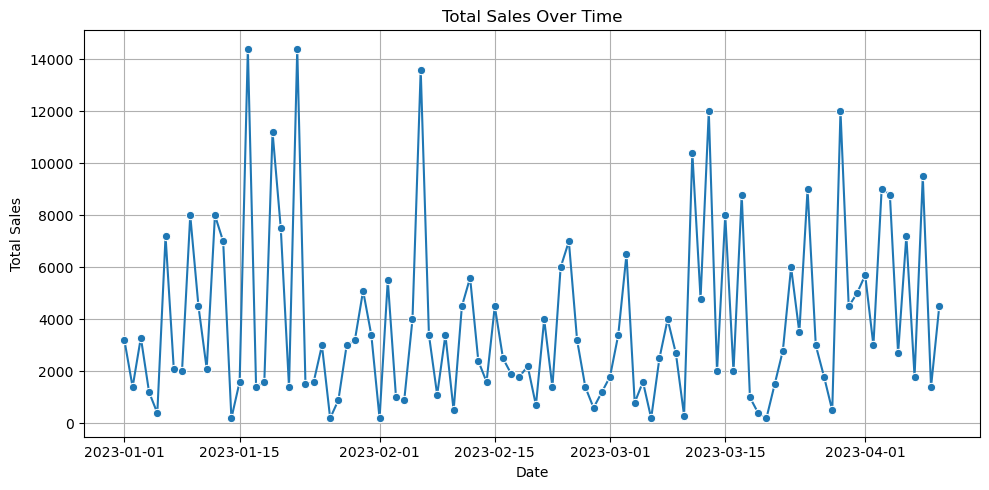

In [16]:

import seaborn as sns
import matplotlib.pyplot as plt

# Convert 'Date' to datetime if not already
data['Date'] = pd.to_datetime(data['Date'])

# Group by date
daily_sales = data.groupby('Date')['Total Sales'].sum().reset_index()

# Plot with Seaborn
plt.figure(figsize=(10, 5))
sns.lineplot(data=daily_sales, x='Date', y='Total Sales', marker='o')
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()




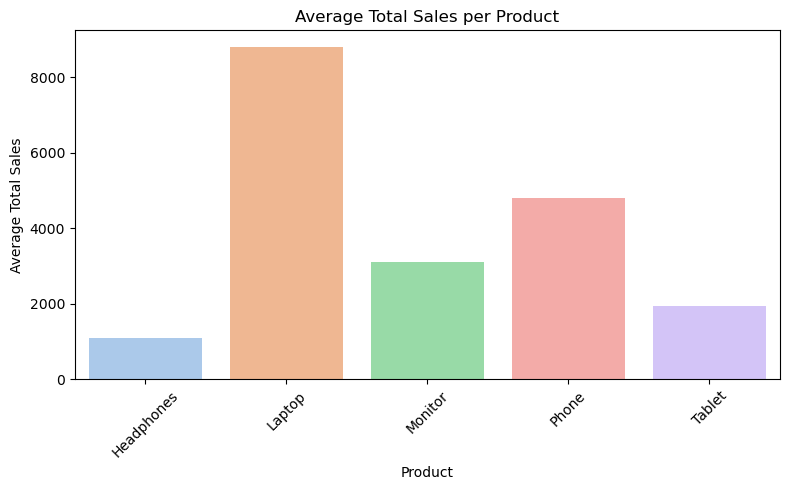

In [19]:

avg_sales = data.groupby('Product')['Total Sales'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_sales, x='Product', y='Total Sales', palette='pastel')
plt.title("Average Total Sales per Product")
plt.xlabel("Product")
plt.ylabel("Average Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()




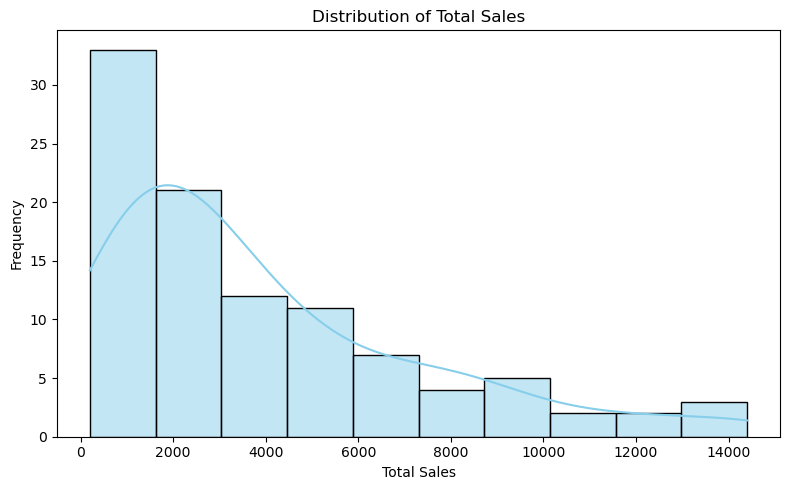

In [17]:
# Create a histogram
plt.figure(figsize=(8, 5))
sns.histplot(data['Total Sales'], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Total Sales")
plt.xlabel("Total Sales")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


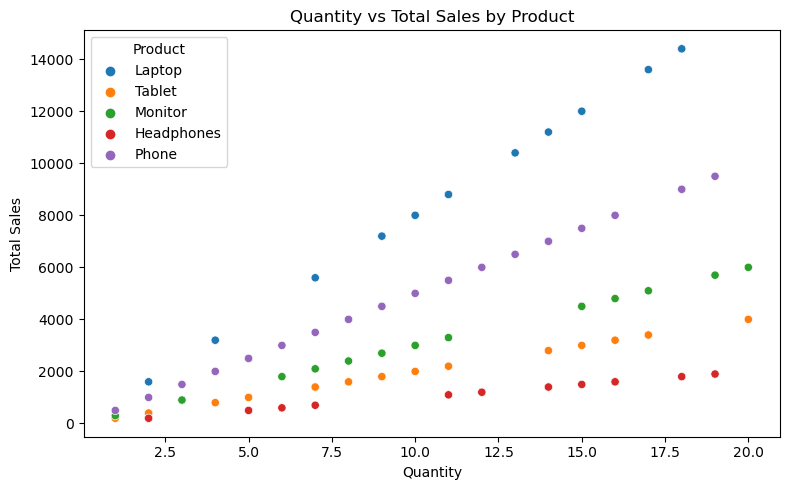

In [15]:
#scatter plot
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.scatterplot(x='Quantity', y='Total Sales', hue='Product', data=df)
plt.title("Quantity vs Total Sales by Product")
plt.xlabel("Quantity")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()
